# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering

Question 1

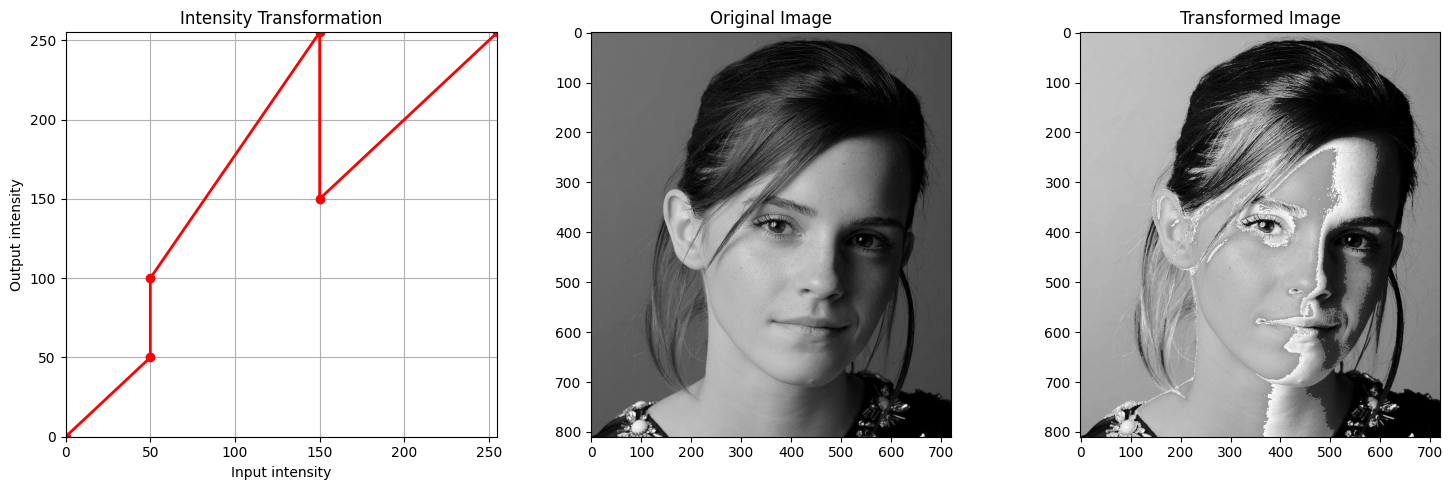

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):

    x_points = breakpoints[:, 0]
    y_points = breakpoints[:, 1]
    
    all_inputs = np.arange(256)
    lut = np.interp(all_inputs, x_points, y_points).astype(np.uint8)
    
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im

breakpoints_fig1a = np.array([
    [0, 0],
    [50, 50],
    [50, 100],   
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

img = cv2.imread('../images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


transformed_img = intensity_transform(img, breakpoints_fig1a)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].plot(breakpoints_fig1a[:, 0], breakpoints_fig1a[:, 1], 'r-o', linewidth=2)
axes[0].set_title("Intensity Transformation")
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image")

axes[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

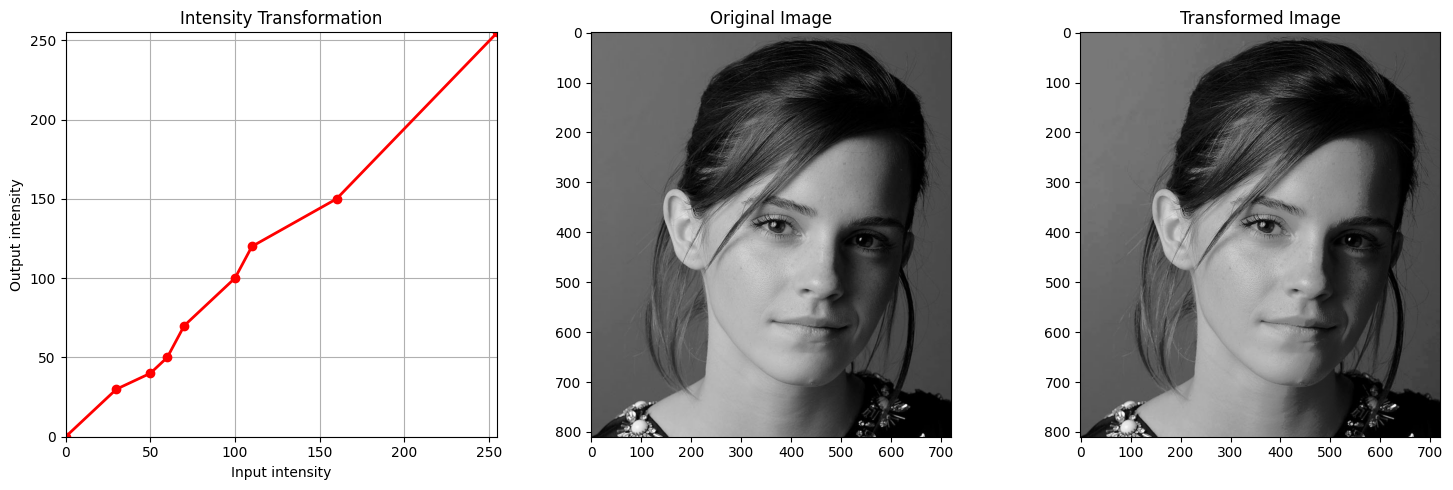

In [3]:
breakpoints_fig1a = np.array([
    [0, 0],
    [30, 30],
    [50, 40],
    [60, 50],  
    [70, 70], 
    [100, 100],
    [110, 120],
    [160, 150],
    [255, 255]
], dtype=np.float32)

img = cv2.imread('../images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


transformed_img = intensity_transform(img, breakpoints_fig1a)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].plot(breakpoints_fig1a[:, 0], breakpoints_fig1a[:, 1], 'r-o', linewidth=2)
axes[0].set_title("Intensity Transformation")
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image")

axes[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

Question 2

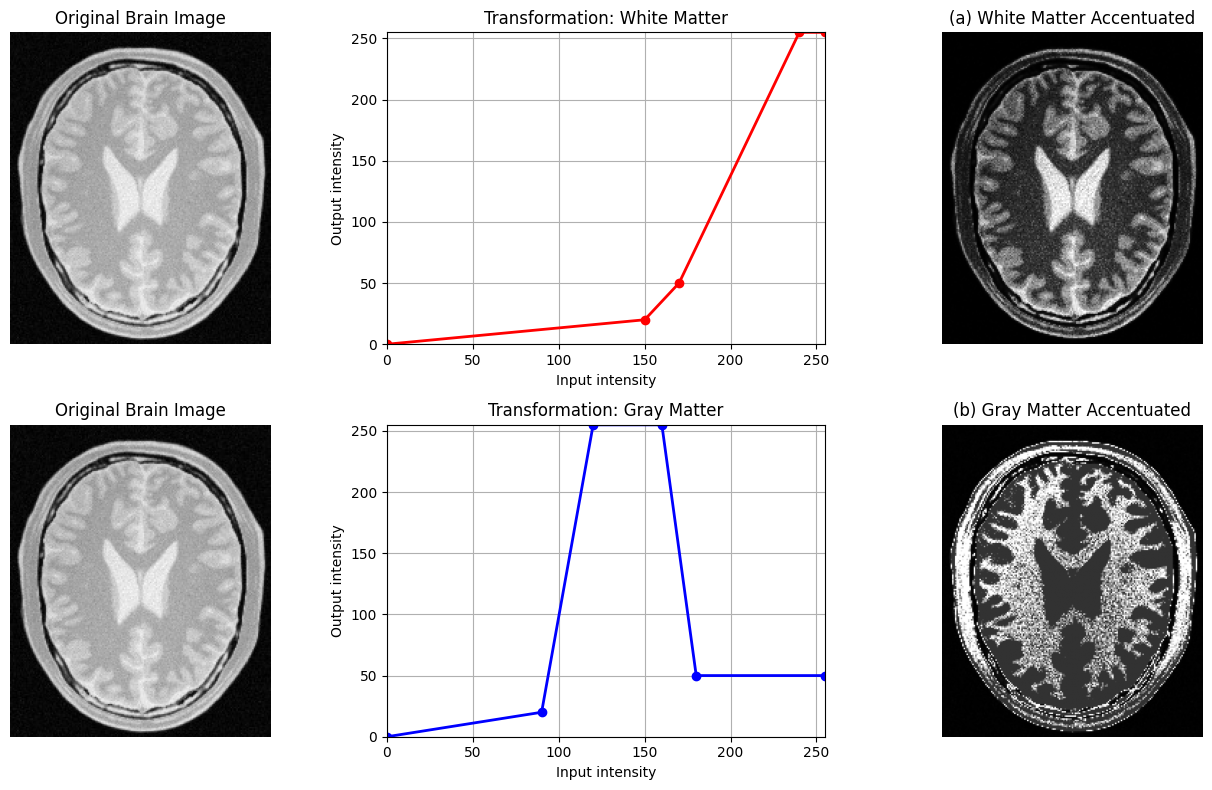

In [4]:
img = cv2.imread('../images/images/q2.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


bp_white_matter = np.array([
    [0, 0],
    [150, 20],  
    [170, 50], 
    [240, 255],  
    [255, 255]
], dtype=np.float32)

bp_gray_matter = np.array([
    [0, 0],
    [90, 20],
    [120, 255], 
    [160, 255],
    [180, 50],   
    [255, 50]
], dtype=np.float32)

img_wm = intensity_transform(img, bp_white_matter)
img_gm = intensity_transform(img, bp_gray_matter)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Brain Image")
axes[0, 0].axis('off')

axes[0, 1].plot(bp_white_matter[:, 0], bp_white_matter[:, 1], 'r-o', linewidth=2)
axes[0, 1].set_title("Transformation: White Matter")
axes[0, 1].set_xlabel("Input intensity")
axes[0, 1].set_ylabel("Output intensity")
axes[0, 1].set_xlim([0, 255])
axes[0, 1].set_ylim([0, 255])
axes[0, 1].grid(True)

axes[0, 2].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("(a) White Matter Accentuated")
axes[0, 2].axis('off')


axes[1, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Original Brain Image")
axes[1, 0].axis('off')

axes[1, 1].plot(bp_gray_matter[:, 0], bp_gray_matter[:, 1], 'b-o', linewidth=2)
axes[1, 1].set_title("Transformation: Gray Matter")
axes[1, 1].set_xlabel("Input intensity")
axes[1, 1].set_ylabel("Output intensity")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_ylim([0, 255])
axes[1, 1].grid(True)

axes[1, 2].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title("(b) Gray Matter Accentuated")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Question 3

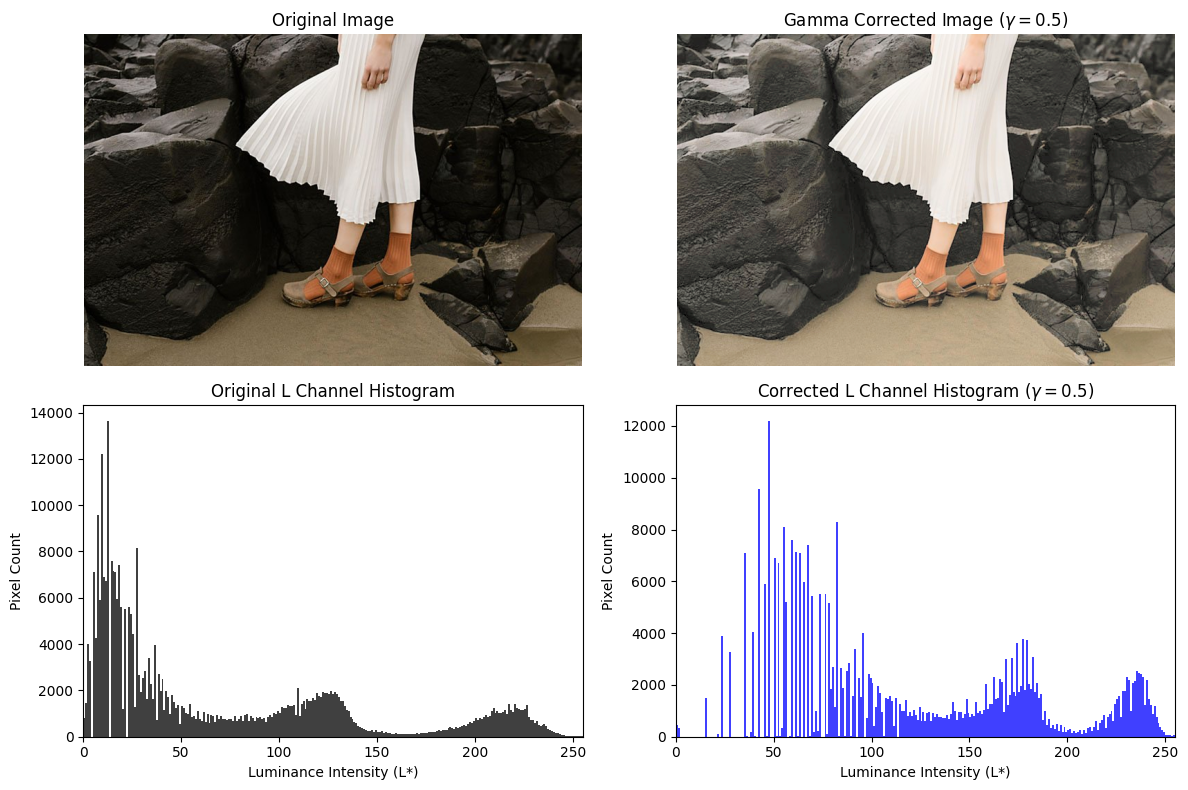

In [5]:
def apply_gamma_lab(image_path, gamma=0.5):
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
        
    rgb_orig = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
    
    L, a, b = cv2.split(lab_img)
    
    L_normalized = L / 255.0
    L_gamma = np.uint8(np.clip(np.power(L_normalized, gamma) * 255.0, 0, 255))

    lab_corrected = cv2.merge([L_gamma, a, b])

    bgr_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    rgb_corrected = cv2.cvtColor(bgr_corrected, cv2.COLOR_BGR2RGB)
    
    return rgb_orig, rgb_corrected, gamma

gamma_val = 0.5 
orig_img, corrected_img, gamma = apply_gamma_lab('../images/images/q3.jpeg', gamma=gamma_val)

lab_orig_L = cv2.cvtColor(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)[:, :, 0]
lab_corr_L = cv2.cvtColor(cv2.cvtColor(corrected_img, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)[:, :, 0]


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(orig_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(corrected_img)
axes[0, 1].set_title(f"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis('off')

axes[1, 0].hist(lab_orig_L.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 0].set_title("Original L Channel Histogram")
axes[1, 0].set_xlabel("Luminance Intensity (L*)")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])


axes[1, 1].hist(lab_corr_L.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.75)
axes[1, 1].set_title(f"Corrected L Channel Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Luminance Intensity (L*)")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])


plt.tight_layout()
plt.show()

Question 3

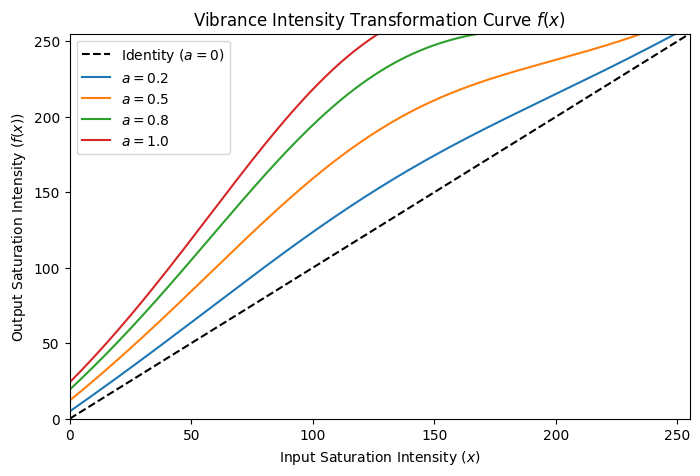

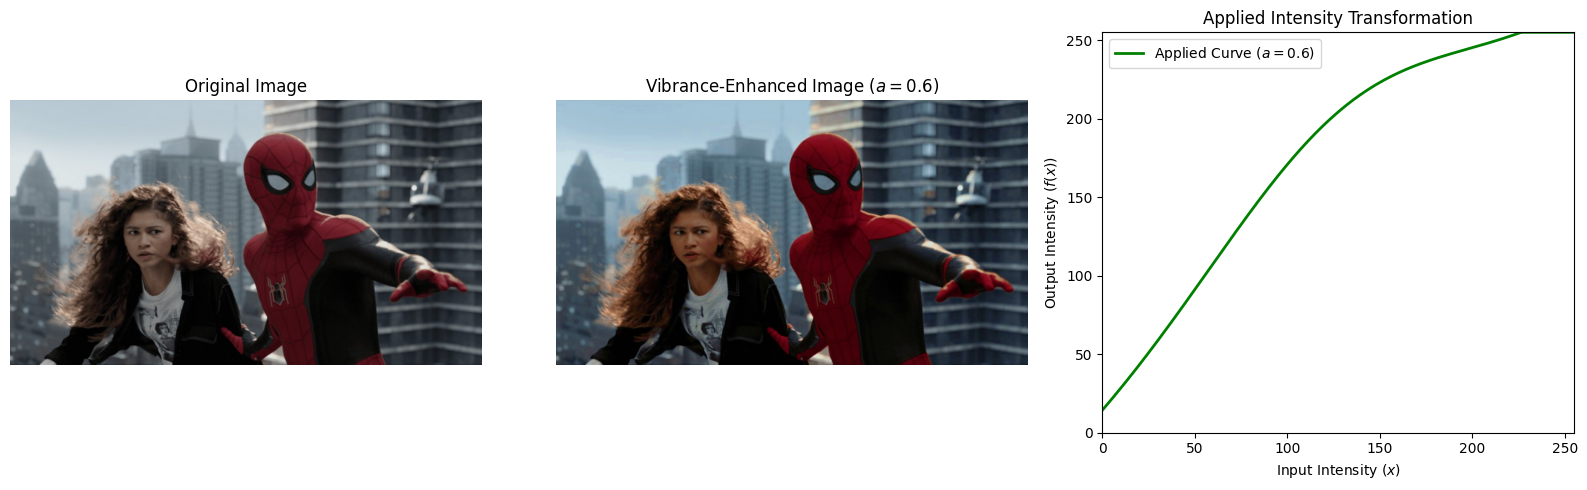

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 256, dtype=np.float32)
sigma = 70.0
a_values = [0.2, 0.5, 0.8, 1.0]

plt.figure(figsize=(8, 5))


plt.plot(x, x, 'k--', label="Identity ($a=0$)")


for a in a_values:
    fx = np.minimum(x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2)), 255.0)
    plt.plot(x, fx, label=f"$a = {a}$")

plt.title("Vibrance Intensity Transformation Curve $f(x)$")
plt.xlabel("Input Saturation Intensity ($x$)")
plt.ylabel("Output Saturation Intensity ($f(x)$)")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.legend()
plt.show()



def enhance_vibrance(image_path, a_param=0.5, sigma_param=70.0):
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
        
    rgb_orig = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    
    hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_img)
    
    x_lut = np.arange(0, 256, dtype=np.float32)
    lut_values = np.minimum(x_lut + a_param * 128.0 * np.exp(-((x_lut - 128.0) ** 2) / (2 * sigma_param ** 2)), 255.0)
    lut = lut_values.astype(np.uint8)
    
    s_enhanced = cv2.LUT(s, lut)
    
    hsv_enhanced = cv2.merge([h, s_enhanced, v])
    bgr_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)
    rgb_enhanced = cv2.cvtColor(bgr_enhanced, cv2.COLOR_BGR2RGB)
    
    return rgb_orig, rgb_enhanced, x_lut, lut_values, a_param

a = 0.6
rgb_orig, rgb_enhanced, x_curve, y_curve, a_val = enhance_vibrance('../images/images/q4.jpeg', a_param=a)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_orig)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(rgb_enhanced)
axes[1].set_title(f"Vibrance-Enhanced Image ($a = {a_val}$)")
axes[1].axis('off')

axes[2].plot(x_curve, y_curve, 'g-', linewidth=2, label=f"Applied Curve ($a={a_val}$)")
axes[2].set_title("Applied Intensity Transformation")
axes[2].set_xlabel("Input Intensity ($x$)")
axes[2].set_ylabel("Output Intensity ($f(x)$)")
axes[2].set_xlim([0, 255])
axes[2].set_ylim([0, 255])
axes[2].legend()

plt.tight_layout()
plt.show()

Question 5

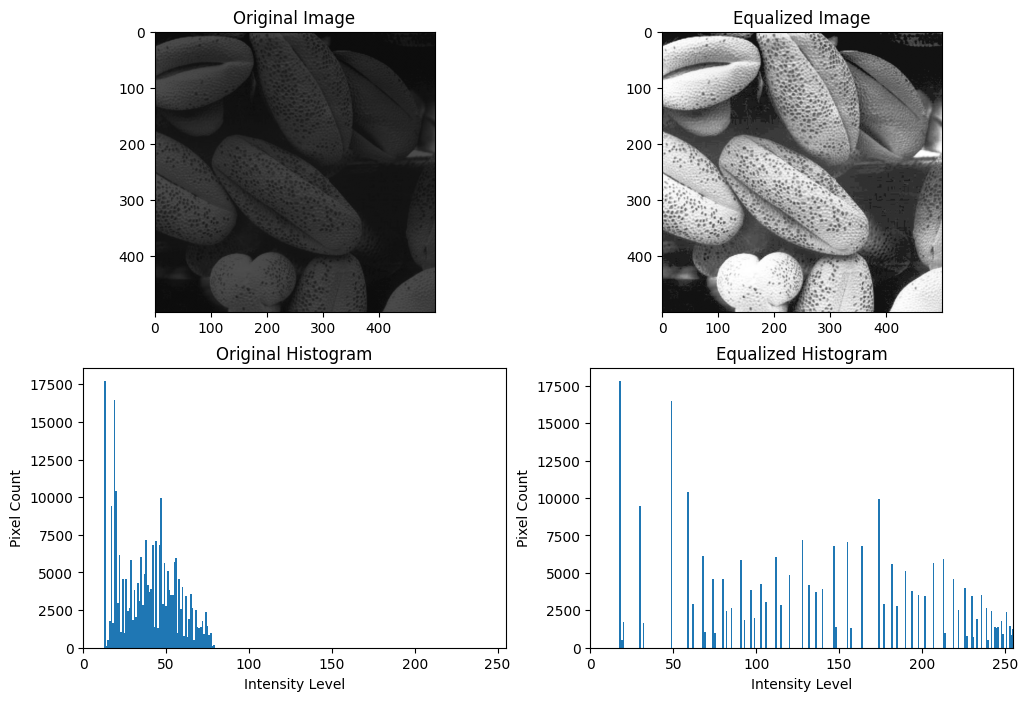

In [11]:
def histogram_equalization(image):
    M, N = image.shape
    pixels = M * N
    L = 256
    histogram_orig = np.zeros(L, dtype=int)
    for pixel_value in image.ravel():
        histogram_orig[pixel_value] += 1

    pmf = histogram_orig/pixels

    cdf = np.cumsum(pmf)

    lut = np.round((L - 1) * cdf).astype(np.uint8)
    equalized_img = lut[image]

    eq_hist = np.zeros(L, dtype=int)
    for pixel_value in equalized_img.ravel():
        eq_hist[pixel_value] += 1

    return equalized_img, histogram_orig, eq_hist


img = cv2.imread('../images/images/shells.tif', cv2.IMREAD_GRAYSCALE)
assert img is not None

img_eq, hist_orig, hist_eq = histogram_equalization(img)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Equalized Image")

axes[1, 0].bar(range(256), hist_orig, width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity Level")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].bar(range(256), hist_eq, width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity Level")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])

plt.show()

Question 6

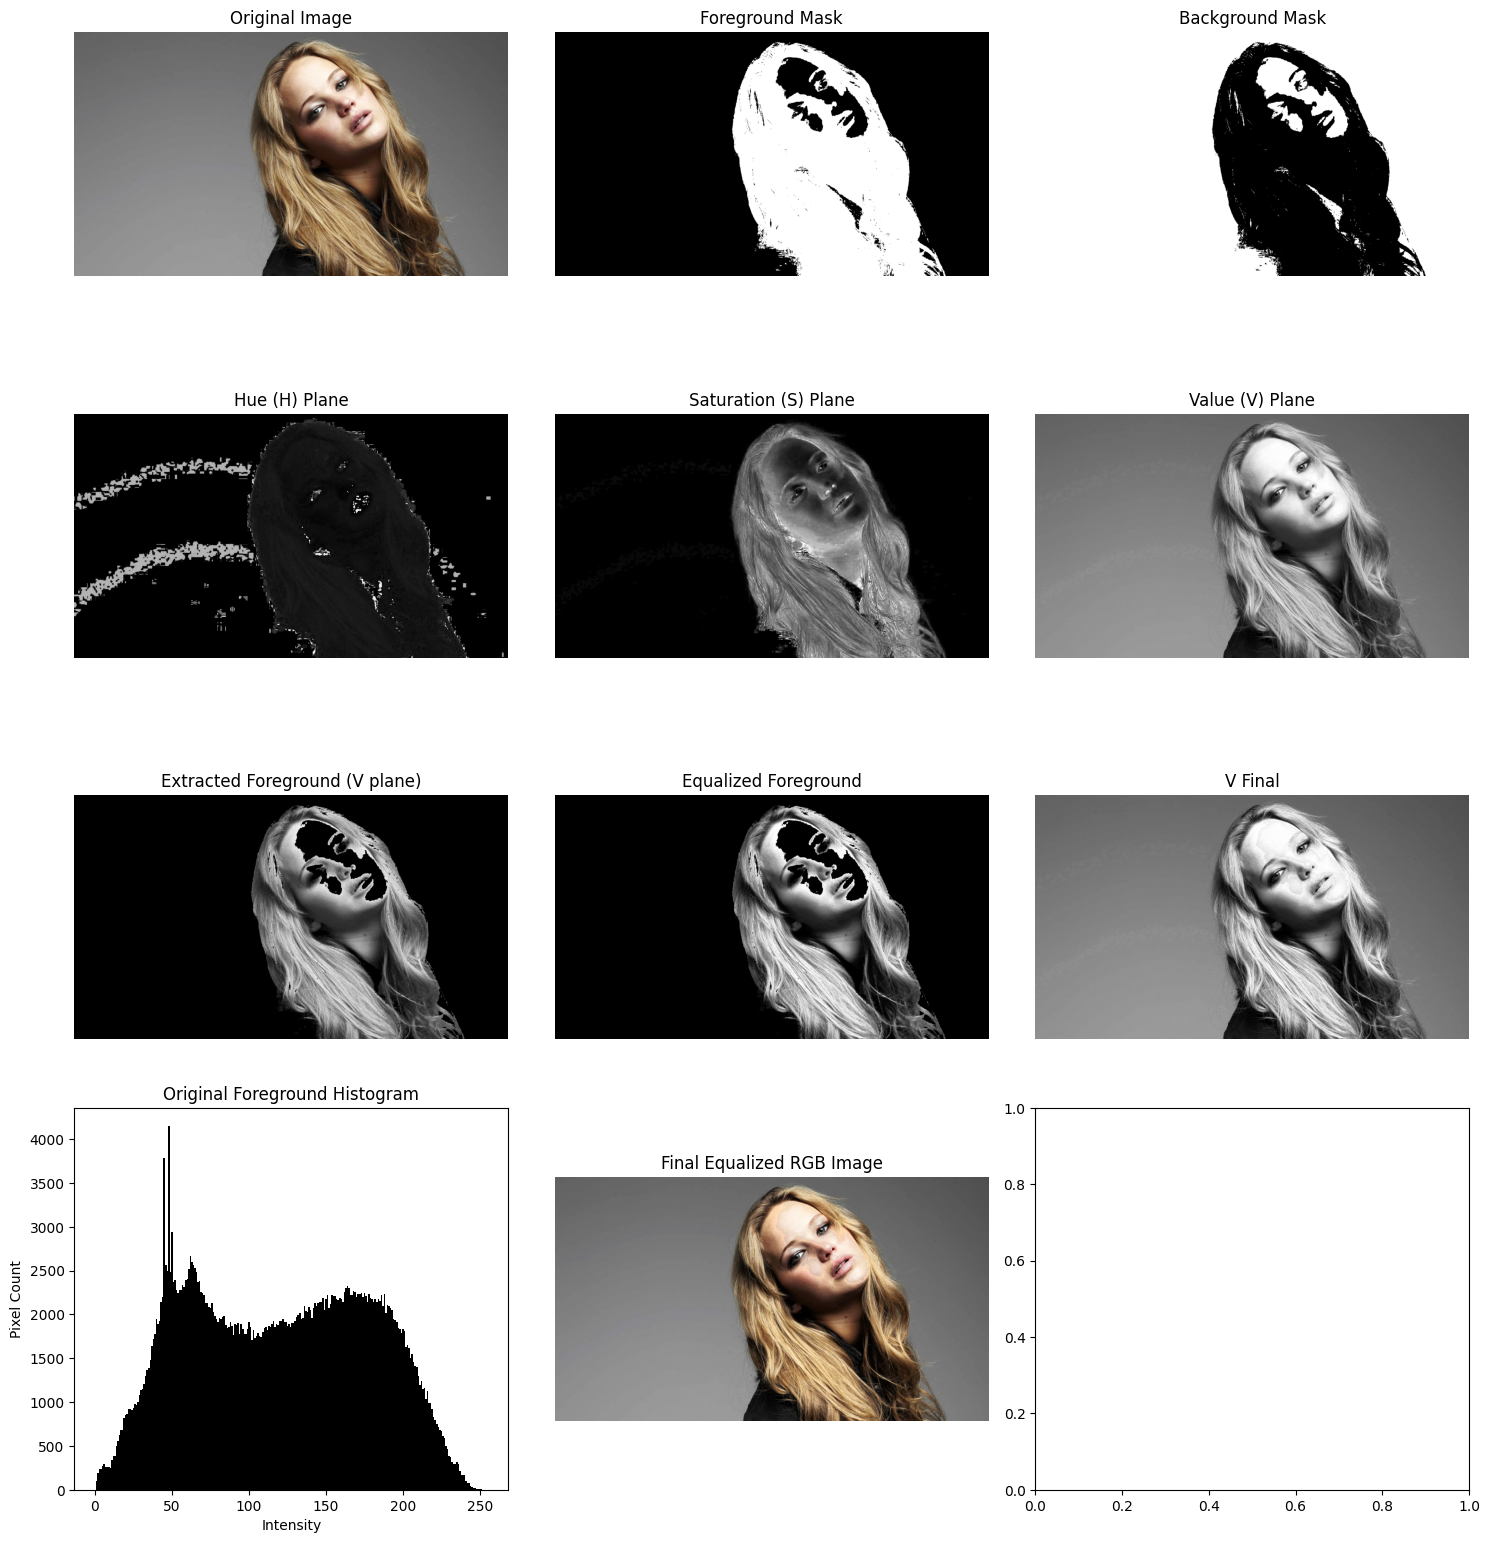

In [10]:
img = cv2.imread('../images/images/q6.jpeg')
assert img is not None

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv_img)

_, foreground_mask = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

background_mask = cv2.bitwise_not(foreground_mask)


foreground = cv2.bitwise_and(V, V, mask=foreground_mask)


fg_pixels = foreground[foreground_mask > 0]
hist, bins = np.histogram(fg_pixels, bins=256, range=[0, 256])


cdf = hist.cumsum()

total_fg_pixels = len(fg_pixels)
L = 256
lut = np.round((L - 1) * cdf / total_fg_pixels).astype(np.uint8)

eq_fore = cv2.LUT(foreground, lut)
eq_fore = cv2.bitwise_and(eq_fore, eq_fore, mask=foreground_mask)


background_V = cv2.bitwise_and(V, V, mask=background_mask)
V_final = cv2.add(background_V, eq_fore)


hsv_final = cv2.merge([H, S, V_final])
result_rgb = cv2.cvtColor(cv2.cvtColor(hsv_final, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)



fig, axes = plt.subplots(4, 3, figsize=(15, 16))


axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(foreground_mask, cmap='gray')
axes[0, 1].set_title("Foreground Mask")
axes[0, 1].axis('off')

axes[0, 2].imshow(background_mask, cmap='gray')
axes[0, 2].set_title("Background Mask")
axes[0, 2].axis('off')


axes[1, 0].imshow(H, cmap='gray')
axes[1, 0].set_title("Hue (H) Plane")
axes[1, 0].axis('off')

axes[1, 1].imshow(S, cmap='gray')
axes[1, 1].set_title("Saturation (S) Plane")
axes[1, 1].axis('off')

axes[1, 2].imshow(V, cmap='gray')
axes[1, 2].set_title("Value (V) Plane")
axes[1, 2].axis('off')


axes[2, 0].imshow(foreground, cmap='gray')
axes[2, 0].set_title("Extracted Foreground (V plane)")
axes[2, 0].axis('off')

axes[2, 1].imshow(eq_fore, cmap='gray')
axes[2, 1].set_title("Equalized Foreground")
axes[2, 1].axis('off')

axes[2, 2].imshow(V_final, cmap='gray')
axes[2, 2].set_title("V Final")
axes[2, 2].axis('off')


axes[3, 0].bar(bins[:-1], hist, width=1.0, color='black')
axes[3, 0].set_title("Original Foreground Histogram")
axes[3, 0].set_xlabel("Intensity")
axes[3, 0].set_ylabel("Pixel Count")


axes[3, 1].imshow(result_rgb)
axes[3, 1].set_title("Final Equalized RGB Image")
axes[3, 1].axis('off')

plt.tight_layout()
plt.show()